In [1]:
# ==========================================
# CELL 1 — UPLOAD DATASET
# ==========================================

from google.colab import files
import pandas as pd
import numpy as np

uploaded = files.upload()

filename = list(uploaded.keys())[0]

print("Uploaded file:", filename)

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Saving sltda_tourist_arrivals_clean_2018_2026.csv to sltda_tourist_arrivals_clean_2018_2026 (1).csv
Uploaded file: sltda_tourist_arrivals_clean_2018_2026 (1).csv
Dataset loaded successfully!
Shape: (20072, 4)


,Year,Month,Country_Clean,Tourist_Arrivals
0,2018,1,AFGHANISTAN,83
1,2018,1,ALBANIA,14
2,2018,1,ALGERIA,38
3,2018,1,ANDORRA,4
4,2018,1,ANGOLA,0


In [2]:
# ==========================================
# CELL 2 — BASIC DATASET CHECK
# ==========================================

print("Rows:", len(df))
print("Columns:", df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nFirst 5 records:")
display(df.head())

Rows: 20072
Columns: ['Year', 'Month', 'Country_Clean', 'Tourist_Arrivals']

Data types:
Year                 int64
Month                int64
Country_Clean       object
Tourist_Arrivals     int64
dtype: object

Missing values:
Year                0
Month               0
Country_Clean       0
Tourist_Arrivals    0
dtype: int64

First 5 records:


,Year,Month,Country_Clean,Tourist_Arrivals
0,2018,1,AFGHANISTAN,83
1,2018,1,ALBANIA,14
2,2018,1,ALGERIA,38
3,2018,1,ANDORRA,4
4,2018,1,ANGOLA,0


In [3]:
# ==========================================
# CELL 3 — DATA TYPE CLEANING
# ==========================================

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Tourist_Arrivals"] = pd.to_numeric(
    df["Tourist_Arrivals"],
    errors="coerce"
)

df["Country_Clean"] = (
    df["Country_Clean"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Remove rows with essential missing values
df = df.dropna(
    subset=[
        "Year",
        "Month",
        "Country_Clean",
        "Tourist_Arrivals"
    ]
).copy()

df["Year"] = df["Year"].astype(int)
df["Month"] = df["Month"].astype(int)
df["Tourist_Arrivals"] = df["Tourist_Arrivals"].astype(float)

print("Cleaned shape:", df.shape)

Cleaned shape: (20072, 4)


In [4]:
# ==========================================
# CELL 4 — CREATE DATE VARIABLE
# ==========================================

df["Date"] = pd.to_datetime(
    dict(
        year=df["Year"],
        month=df["Month"],
        day=1
    )
)

df = df.sort_values(
    ["Country_Clean", "Date"]
).reset_index(drop=True)

print("Date range:")
print(df["Date"].min(), "to", df["Date"].max())

display(df.head())

Date range:
2018-01-01 00:00:00 to 2026-09-01 00:00:00


,Year,Month,Country_Clean,Tourist_Arrivals,Date
0,2018,1,AFGHANISTAN,83.0,2018-01-01
1,2018,2,AFGHANISTAN,150.0,2018-02-01
2,2018,3,AFGHANISTAN,112.0,2018-03-01
3,2018,4,AFGHANISTAN,40.0,2018-04-01
4,2018,5,AFGHANISTAN,108.0,2018-05-01


In [5]:
# ==========================================
# CELL 5 — DUPLICATE CHECK
# ==========================================

duplicates = df.duplicated(
    subset=[
        "Country_Clean",
        "Year",
        "Month"
    ]
).sum()

print("Duplicate country-month records:", duplicates)

Duplicate country-month records: 0


In [6]:
# ==========================================
# CELL 6 — FEATURE ENGINEERING
# ==========================================

# Previous month's tourist arrivals
df["Previous_Month_Arrivals"] = (
    df.groupby("Country_Clean")["Tourist_Arrivals"]
      .shift(1)
)

# Same month in previous year
df["Previous_Year_Same_Month"] = (
    df.groupby("Country_Clean")["Tourist_Arrivals"]
      .shift(12)
)

# Previous 3-month average
df["Rolling_3_Month_Average"] = (
    df.groupby("Country_Clean")["Tourist_Arrivals"]
      .shift(1)
      .rolling(window=3)
      .mean()
      .reset_index(level=0, drop=True)
)

display(
    df[
        [
            "Year",
            "Month",
            "Country_Clean",
            "Tourist_Arrivals",
            "Previous_Month_Arrivals",
            "Previous_Year_Same_Month",
            "Rolling_3_Month_Average"
        ]
    ].head(20)
)

,Year,Month,Country_Clean,Tourist_Arrivals,Previous_Month_Arrivals,Previous_Year_Same_Month,Rolling_3_Month_Average
0,2018,1,AFGHANISTAN,83.0,NaN,NaN,NaN
1,2018,2,AFGHANISTAN,150.0,83.0,NaN,NaN
2,2018,3,AFGHANISTAN,112.0,150.0,NaN,NaN
3,2018,4,AFGHANISTAN,40.0,112.0,NaN,115.000000
4,2018,5,AFGHANISTAN,108.0,40.0,NaN,100.666667
5,2018,6,AFGHANISTAN,44.0,108.0,NaN,86.666667
6,2018,7,AFGHANISTAN,47.0,44.0,NaN,64.000000
7,2018,8,AFGHANISTAN,78.0,47.0,NaN,66.333333
8,2018,9,AFGHANISTAN,34.0,78.0,NaN,56.333333
9,2018,10,AFGHANISTAN,41.0,34.0,NaN,53.000000


In [7]:
# ==========================================
# CELL 7 — PREPARE MODELING DATA
# ==========================================

model_df = df.dropna(
    subset=[
        "Previous_Month_Arrivals",
        "Previous_Year_Same_Month",
        "Rolling_3_Month_Average"
    ]
).copy()

print("Original records:", len(df))
print("Records available for ML:", len(model_df))
print("Records removed:", len(df) - len(model_df))

print("\nMissing values after preparation:")
print(
    model_df[
        [
            "Previous_Month_Arrivals",
            "Previous_Year_Same_Month",
            "Rolling_3_Month_Average"
        ]
    ].isnull().sum()
)

Original records: 20072
Records available for ML: 17420
Records removed: 2652

Missing values after preparation:
Previous_Month_Arrivals     0
Previous_Year_Same_Month    0
Rolling_3_Month_Average     0
dtype: int64


In [8]:
# ==========================================
# CELL 8 — DEFINE FEATURES AND TARGET
# ==========================================

features = [
    "Country_Clean",
    "Year",
    "Month",
    "Previous_Month_Arrivals",
    "Previous_Year_Same_Month",
    "Rolling_3_Month_Average"
]

target = "Tourist_Arrivals"

X = model_df[features]
y = model_df[target]

print("Features:")
for feature in features:
    print("-", feature)

print("\nTarget:", target)

Features:
- Country_Clean
- Year
- Month
- Previous_Month_Arrivals
- Previous_Year_Same_Month
- Rolling_3_Month_Average

Target: Tourist_Arrivals


In [9]:
# ==========================================
# CELL 9 — TIME-BASED SPLIT
# ==========================================

train_df = model_df[
    model_df["Year"] <= 2024
].copy()

validation_df = model_df[
    model_df["Year"] == 2025
].copy()

test_df = model_df[
    model_df["Year"] == 2026
].copy()

print("Training records:", len(train_df))
print("Validation records:", len(validation_df))
print("Test records:", len(test_df))

print("\nTraining period:",
      train_df["Date"].min(),
      "to",
      train_df["Date"].max())

print("Validation period:",
      validation_df["Date"].min(),
      "to",
      validation_df["Date"].max())

print("Test period:",
      test_df["Date"].min(),
      "to",
      test_df["Date"].max())

Training records: 13388
Validation records: 2304
Test records: 1728

Training period: 2019-01-01 00:00:00 to 2024-12-01 00:00:00
Validation period: 2025-01-01 00:00:00 to 2025-12-01 00:00:00
Test period: 2026-01-01 00:00:00 to 2026-09-01 00:00:00


In [10]:
# ==========================================
# CELL 10 — CREATE TRAIN/VALIDATION/TEST SETS
# ==========================================

X_train = train_df[features]
y_train = train_df[target]

X_validation = validation_df[features]
y_validation = validation_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (13388, 6)
y_train: (13388,)
X_validation: (2304, 6)
y_validation: (2304,)
X_test: (1728, 6)
y_test: (1728,)


In [11]:
# ==========================================
# CELL 11 — PREPROCESSING
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Country_Clean"
]

numerical_features = [
    "Year",
    "Month",
    "Previous_Month_Arrivals",
    "Previous_Year_Same_Month",
    "Rolling_3_Month_Average"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "country",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

print("Preprocessor ready.")

Preprocessor ready.


In [12]:
# ==========================================
# CELL 12 — RANDOM FOREST MODEL
# ==========================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=2
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", rf_model)
    ]
)

print("Random Forest model created.")

Random Forest model created.


In [13]:
# ==========================================
# CELL 13 — TRAIN MODEL
# ==========================================

model.fit(
    X_train,
    y_train
)

print("Model training completed successfully!")

Model training completed successfully!


In [14]:
# ==========================================
# CELL 14 — VALIDATION PREDICTIONS
# ==========================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_validation_pred = model.predict(
    X_validation
)

mae_validation = mean_absolute_error(
    y_validation,
    y_validation_pred
)

rmse_validation = np.sqrt(
    mean_squared_error(
        y_validation,
        y_validation_pred
    )
)

r2_validation = r2_score(
    y_validation,
    y_validation_pred
)

print("2025 VALIDATION RESULTS")
print("=======================")
print("MAE :", round(mae_validation, 2))
print("RMSE:", round(rmse_validation, 2))
print("R²  :", round(r2_validation, 4))

2025 VALIDATION RESULTS
MAE : 230.51
RMSE: 1040.89
R²  : 0.9364


In [15]:
# ==========================================
# CELL 15 — FINAL TEST
# ==========================================

y_test_pred = model.predict(
    X_test
)

mae_test = mean_absolute_error(
    y_test,
    y_test_pred
)

rmse_test = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred
    )
)

r2_test = r2_score(
    y_test,
    y_test_pred
)

print("2026 TEST RESULTS")
print("=================")
print("MAE :", round(mae_test, 2))
print("RMSE:", round(rmse_test, 2))
print("R²  :", round(r2_test, 4))

2026 TEST RESULTS
MAE : 282.14
RMSE: 1200.94
R²  : 0.9209


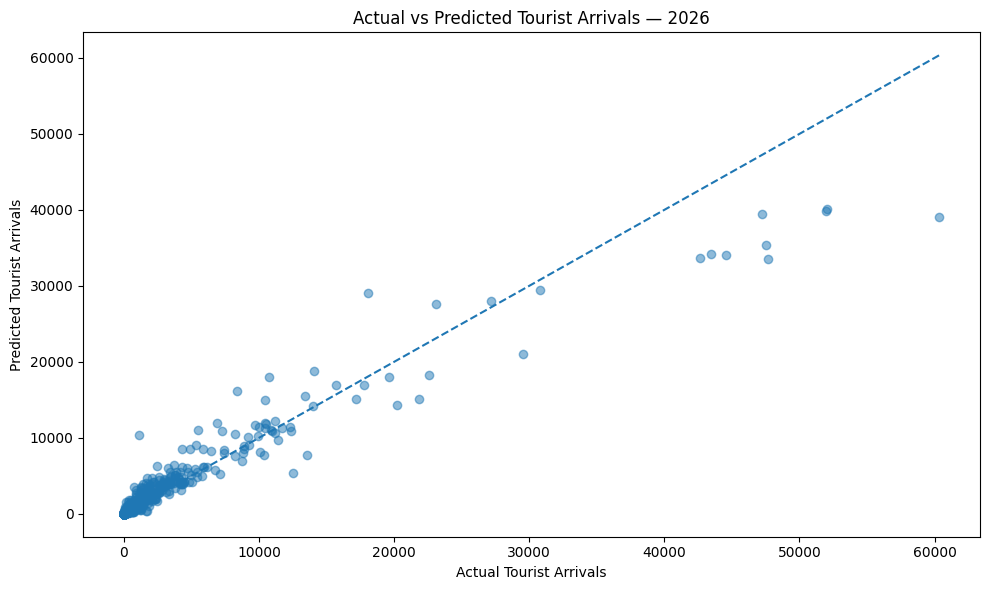

In [16]:
# ==========================================
# CELL 16 — ACTUAL VS PREDICTED
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.5
)

max_value = max(
    y_test.max(),
    y_test_pred.max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Actual Tourist Arrivals")
plt.ylabel("Predicted Tourist Arrivals")

plt.title(
    "Actual vs Predicted Tourist Arrivals — 2026"
)

plt.tight_layout()
plt.show()

In [17]:
# ==========================================
# CELL 17 — FINAL FORECASTING MODEL
# ==========================================

X_all = model_df[features]
y_all = model_df[target]

final_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=2
)

final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", final_rf)
    ]
)

final_model.fit(
    X_all,
    y_all
)

print("Final forecasting model trained!")
print("Historical ML records:", len(model_df))

Final forecasting model trained!
Historical ML records: 17420


In [18]:
# ==========================================
# CELL 18 — FORECAST HISTORY
# ==========================================

forecast_history = df[
    [
        "Country_Clean",
        "Date",
        "Tourist_Arrivals"
    ]
].copy()

forecast_history = forecast_history.sort_values(
    ["Country_Clean", "Date"]
).reset_index(drop=True)

# Use countries that have observations in 2026
forecast_countries = sorted(
    df[
        df["Year"] == 2026
    ]["Country_Clean"].unique()
)

print(
    "Countries included in future forecasting:",
    len(forecast_countries)
)

print(
    "Latest actual data:",
    forecast_history["Date"].max()
)

Countries included in future forecasting: 192
Latest actual data: 2026-09-01 00:00:00


In [29]:
# ==========================================
# CELL 19 — FUTURE FORECAST
# OCTOBER 2026 → DECEMBER 2031
# ==========================================

future_dates = pd.date_range(
    start="2026-10-01",
    end="2031-12-01",
    freq="MS"
)

future_predictions = []

for current_date in future_dates:

    rows = []

    for country in forecast_countries:

        country_history = forecast_history[
            forecast_history["Country_Clean"] == country
        ].sort_values("Date")

        # -----------------------------
        # Previous month
        # -----------------------------
        previous_month_date = (
            current_date - pd.DateOffset(months=1)
        )

        previous_month = country_history[
            country_history["Date"] == previous_month_date
        ]

        if len(previous_month) == 0:
            continue

        previous_month_arrivals = (
            previous_month["Tourist_Arrivals"].iloc[0]
        )

        # -----------------------------
        # Same month previous year
        # -----------------------------
        previous_year_date = (
            current_date - pd.DateOffset(months=12)
        )

        previous_year = country_history[
            country_history["Date"] == previous_year_date
        ]

        if len(previous_year) == 0:
            continue

        previous_year_arrivals = (
            previous_year["Tourist_Arrivals"].iloc[0]
        )

        # -----------------------------
        # Previous 3 months
        # -----------------------------
        last_three_dates = [
            current_date - pd.DateOffset(months=1),
            current_date - pd.DateOffset(months=2),
            current_date - pd.DateOffset(months=3)
        ]

        last_three_values = []

        for date_value in last_three_dates:

            previous_row = country_history[
                country_history["Date"] == date_value
            ]

            if len(previous_row) > 0:

                last_three_values.append(
                    previous_row[
                        "Tourist_Arrivals"
                    ].iloc[0]
                )

        if len(last_three_values) < 3:
            continue

        rolling_average = np.mean(
            last_three_values
        )

        # -----------------------------
        # Create feature row
        # -----------------------------
        rows.append({
            "Country_Clean": country,
            "Year": current_date.year,
            "Month": current_date.month,
            "Previous_Month_Arrivals":
                previous_month_arrivals,
            "Previous_Year_Same_Month":
                previous_year_arrivals,
            "Rolling_3_Month_Average":
                rolling_average
        })

    if len(rows) == 0:
        continue

    future_features = pd.DataFrame(rows)

    # -----------------------------
    # Predict
    # -----------------------------
    predictions = final_model.predict(
        future_features[features]
    )

    # No negative arrivals
    predictions = np.maximum(
        predictions,
        0
    )

    future_features[
        "Predicted_Arrivals"
    ] = predictions

    future_features[
        "Date"
    ] = current_date

    # -----------------------------
    # Add predictions to history
    # -----------------------------
    new_history = future_features[
        [
            "Country_Clean",
            "Date",
            "Predicted_Arrivals"
        ]
    ].copy()

    new_history = new_history.rename(
        columns={
            "Predicted_Arrivals":
                "Tourist_Arrivals"
        }
    )

    forecast_history = pd.concat(
        [
            forecast_history,
            new_history
        ],
        ignore_index=True
    )

    future_predictions.append(
        future_features
    )

# Combine all predictions
future_forecast = pd.concat(
    future_predictions,
    ignore_index=True
)

print("Future forecasting completed!")

print(
    "Forecast period:",
    future_forecast["Date"].min(),
    "to",
    future_forecast["Date"].max()
)

print(
    "Forecast records:",
    len(future_forecast)
)

Future forecasting completed!
Forecast period: 2026-10-01 00:00:00 to 2031-12-01 00:00:00
Forecast records: 11907


In [30]:
# ==========================================
# CELL 20 — TOTAL MONTHLY FORECAST
# ==========================================

monthly_forecast = (
    future_forecast
    .groupby("Date")["Predicted_Arrivals"]
    .sum()
    .reset_index()
)

monthly_forecast[
    "Predicted_Arrivals"
] = (
    monthly_forecast[
        "Predicted_Arrivals"
    ]
    .round()
    .astype(int)
)

display(monthly_forecast.head())

,Date,Predicted_Arrivals
0,2026-10-01,176395
1,2026-11-01,217836
2,2026-12-01,266023
3,2027-01-01,278047
4,2027-02-01,286188


In [31]:
# ==========================================
# CELL 21 — ANNUAL FORECAST
# ==========================================

annual_forecast = (
    monthly_forecast
    .assign(
        Year=monthly_forecast["Date"].dt.year
    )
    .groupby("Year")["Predicted_Arrivals"]
    .sum()
    .reset_index()
)

annual_forecast[
    "Predicted_Arrivals"
] = (
    annual_forecast[
        "Predicted_Arrivals"
    ]
    .round()
    .astype(int)
)

display(annual_forecast)

,Year,Predicted_Arrivals
0,2026,660254
1,2027,2473036
2,2028,2579713
3,2029,2656167
4,2030,2716864
5,2031,2783073


In [32]:
# ==========================================
# CELL 22 — COUNTRY-LEVEL FORECAST
# ==========================================

country_month_forecast = (
    future_forecast[
        [
            "Date",
            "Country_Clean",
            "Predicted_Arrivals"
        ]
    ]
    .copy()
)

country_month_forecast[
    "Predicted_Arrivals"
] = (
    country_month_forecast[
        "Predicted_Arrivals"
    ]
    .round()
    .astype(int)
)

display(
    country_month_forecast.head(20)
)

,Date,Country_Clean,Predicted_Arrivals
0,2026-10-01,AFGHANISTAN,9
1,2026-10-01,ALBANIA,10
2,2026-10-01,ALGERIA,49
3,2026-10-01,ANDORRA,16
4,2026-10-01,ANGOLA,2
5,2026-10-01,ANTIGUA AND BARBUDA,1
6,2026-10-01,ARGENTINA,82
7,2026-10-01,ARMENIA,370
8,2026-10-01,AUSTRALIA,9730
9,2026-10-01,AUSTRIA,869


In [33]:
# ==========================================
# CELL 23 — COUNTRY ANNUAL FORECAST
# ==========================================

country_annual_forecast = (
    future_forecast
    .assign(
        Year=future_forecast["Date"].dt.year
    )
    .groupby(
        ["Year", "Country_Clean"]
    )["Predicted_Arrivals"]
    .sum()
    .reset_index()
)

country_annual_forecast[
    "Predicted_Arrivals"
] = (
    country_annual_forecast[
        "Predicted_Arrivals"
    ]
    .round()
    .astype(int)
)

display(
    country_annual_forecast.head(20)
)

,Year,Country_Clean,Predicted_Arrivals
0,2026,AFGHANISTAN,25
1,2026,ALBANIA,34
2,2026,ALGERIA,257
3,2026,ANDORRA,44
4,2026,ANGOLA,8
5,2026,ANTIGUA AND BARBUDA,7
6,2026,ARGENTINA,304
7,2026,ARMENIA,1129
8,2026,AUSTRALIA,36238
9,2026,AUSTRIA,5072


In [25]:
predict_month(2027, 3)

217325

In [34]:
# ==========================================
# CELL 24 — INTERACTIVE TOURIST FORECAST
# ==========================================

import ipywidgets as widgets
from IPython.display import display, clear_output

# ------------------------------------------
# Available years
# ------------------------------------------

available_years = sorted(
    monthly_forecast["Date"]
    .dt.year
    .unique()
)

# ------------------------------------------
# Available countries
# ------------------------------------------

available_countries = sorted(
    country_month_forecast[
        "Country_Clean"
    ].unique()
)

country_options = [
    "ALL COUNTRIES"
] + available_countries

# ------------------------------------------
# Widgets
# ------------------------------------------

country_dropdown = widgets.Dropdown(
    options=country_options,
    value="ALL COUNTRIES",
    description="Country:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="400px")
)

year_dropdown = widgets.Dropdown(
    options=available_years,
    description="Year:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="300px")
)

month_dropdown = widgets.Dropdown(
    options=[
        ("January", 1),
        ("February", 2),
        ("March", 3),
        ("April", 4),
        ("May", 5),
        ("June", 6),
        ("July", 7),
        ("August", 8),
        ("September", 9),
        ("October", 10),
        ("November", 11),
        ("December", 12)
    ],
    description="Month:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="300px")
)

predict_button = widgets.Button(
    description="Predict",
    button_style="primary",
    icon="search"
)

output = widgets.Output()

# ------------------------------------------
# Prediction function
# ------------------------------------------

def on_predict_clicked(button):

    with output:

        clear_output()

        selected_country = country_dropdown.value
        selected_year = year_dropdown.value
        selected_month = month_dropdown.value

        selected_date = pd.Timestamp(
            year=selected_year,
            month=selected_month,
            day=1
        )

        # ==================================
        # ALL COUNTRIES
        # ==================================

        if selected_country == "ALL COUNTRIES":

            result = monthly_forecast[
                monthly_forecast["Date"]
                == selected_date
            ]

            if len(result) == 0:

                print(
                    "Forecast is not available "
                    "for this period."
                )

            else:

                value = int(
                    result[
                        "Predicted_Arrivals"
                    ].iloc[0]
                )

                print("=" * 55)
                print(
                    "🇱🇰 SRI LANKA — TOTAL TOURIST FORECAST"
                )
                print("=" * 55)

                print(
                    f"Period: "
                    f"{selected_year}-"
                    f"{selected_month:02d}"
                )

                print()

                print(
                    f"Predicted arrivals: "
                    f"{value:,} tourists"
                )

                print("=" * 55)

        # ==================================
        # SPECIFIC COUNTRY
        # ==================================

        else:

            result = country_month_forecast[
                (
                    country_month_forecast[
                        "Date"
                    ] == selected_date
                )
                &
                (
                    country_month_forecast[
                        "Country_Clean"
                    ] == selected_country
                )
            ]

            if len(result) == 0:

                print(
                    "Forecast is not available "
                    "for this country and period."
                )

            else:

                value = int(
                    result[
                        "Predicted_Arrivals"
                    ].iloc[0]
                )

                print("=" * 55)
                print(
                    "🌍 COUNTRY TOURIST FORECAST"
                )
                print("=" * 55)

                print(
                    f"Country: {selected_country}"
                )

                print(
                    f"Period: "
                    f"{selected_year}-"
                    f"{selected_month:02d}"
                )

                print()

                print(
                    f"Predicted arrivals: "
                    f"{value:,} tourists"
                )

                print("=" * 55)


predict_button.on_click(
    on_predict_clicked
)

# ------------------------------------------
# Display
# ------------------------------------------

display(
    country_dropdown,
    year_dropdown,
    month_dropdown,
    predict_button,
    output
)

Dropdown(description='Country:', layout=Layout(width='400px'), options=('ALL COUNTRIES', 'AFGHANISTAN', 'ALBAN…

Dropdown(description='Year:', layout=Layout(width='300px'), options=(np.int32(2026), np.int32(2027), np.int32(…

Dropdown(description='Month:', layout=Layout(width='300px'), options=(('January', 1), ('February', 2), ('March…

Button(button_style='primary', description='Predict', icon='search', style=ButtonStyle())

Output()

In [27]:
predict_year(2027)

2473036

In [35]:
# ==========================================
# CELL 25 — TOP PREDICTED SOURCE COUNTRIES
# ==========================================

def top_predicted_countries(year, month, top_n=10):

    selected_date = pd.Timestamp(
        year=int(year),
        month=int(month),
        day=1
    )

    result = country_month_forecast[
        country_month_forecast["Date"] == selected_date
    ].copy()

    if len(result) == 0:
        print("Forecast is not available for this period.")
        return

    # Sort by predicted arrivals
    result = result.sort_values(
        "Predicted_Arrivals",
        ascending=False
    )

    # Select top countries
    result = result.head(top_n).copy()

    # Reset ranking
    result.insert(
        0,
        "Rank",
        range(1, len(result) + 1)
    )

    # Rename columns for display
    result = result.rename(
        columns={
            "Country_Clean": "Country",
            "Predicted_Arrivals":
                "Predicted Arrivals"
        }
    )

    result["Predicted Arrivals"] = (
        result["Predicted Arrivals"]
        .map(lambda x: f"{x:,}")
    )

    print("=" * 60)
    print(
        f"TOP {top_n} PREDICTED TOURIST SOURCE COUNTRIES"
    )
    print("=" * 60)

    print(
        f"Forecast period: "
        f"{year}-{month:02d}"
    )

    print()

    display(
        result[
            [
                "Rank",
                "Country",
                "Predicted Arrivals"
            ]
        ]
    )

In [36]:
top_predicted_countries(
    2027,
    3,
    10
)

TOP 10 PREDICTED TOURIST SOURCE COUNTRIES
Forecast period: 2027-03



,Rank,Country,Predicted Arrivals
1018,1,INDIA,"53,597"
980,2,CHINA,"16,654"
1124,3,UNITED KINGDOM,"16,270"
1084,4,RUSSIA,"15,930"
1006,5,GERMANY,"15,100"
1002,6,FRANCE,"12,339"
953,7,AUSTRALIA,"11,991"
1079,8,POLAND,"7,437"
1125,9,UNITED STATES,"5,618"
1026,10,JAPAN,"4,316"


In [37]:
# ==========================================
# CELL 26 — TOP COUNTRIES VISUALIZATION
# ==========================================

def plot_top_predicted_countries(
    year,
    month,
    top_n=10
):

    selected_date = pd.Timestamp(
        year=int(year),
        month=int(month),
        day=1
    )

    result = country_month_forecast[
        country_month_forecast["Date"] == selected_date
    ].copy()

    if len(result) == 0:
        print("Forecast is not available for this period.")
        return

    # Top countries
    result = result.sort_values(
        "Predicted_Arrivals",
        ascending=False
    ).head(top_n)

    # Reverse for horizontal bar chart
    result = result.sort_values(
        "Predicted_Arrivals"
    )

    plt.figure(figsize=(10, 6))

    plt.barh(
        result["Country_Clean"],
        result["Predicted_Arrivals"]
    )

    plt.xlabel(
        "Predicted Tourist Arrivals"
    )

    plt.ylabel("Country")

    plt.title(
        f"Top {top_n} Predicted Tourist Source Countries — "
        f"{year}-{month:02d}"
    )

    plt.tight_layout()
    plt.show()

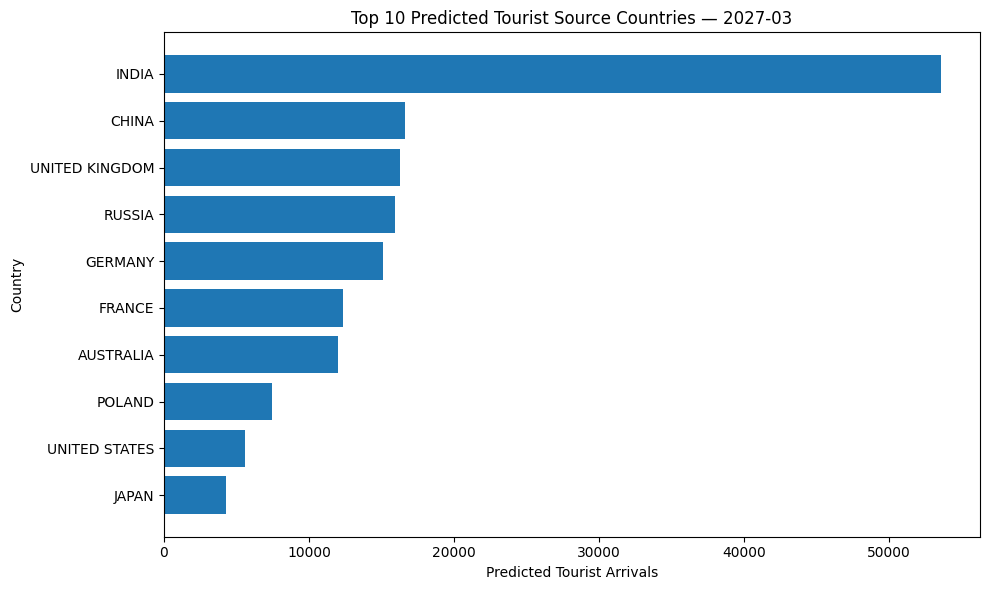

In [38]:
plot_top_predicted_countries(
    2027,
    3,
    10
)

In [39]:
# ==========================================
# CELL 27 — INTERACTIVE TOP COUNTRY RANKING
# ==========================================

ranking_year = widgets.Dropdown(
    options=available_years,
    description="Year:",
    style={"description_width": "initial"}
)

ranking_month = widgets.Dropdown(
    options=[
        ("January", 1),
        ("February", 2),
        ("March", 3),
        ("April", 4),
        ("May", 5),
        ("June", 6),
        ("July", 7),
        ("August", 8),
        ("September", 9),
        ("October", 10),
        ("November", 11),
        ("December", 12)
    ],
    description="Month:",
    style={"description_width": "initial"}
)

top_n_dropdown = widgets.Dropdown(
    options=[5, 10, 15, 20],
    value=10,
    description="Show top:",
    style={"description_width": "initial"}
)

ranking_button = widgets.Button(
    description="Show Top Countries",
    button_style="primary"
)

ranking_output = widgets.Output()


def show_ranking(button):

    with ranking_output:

        clear_output()

        year = ranking_year.value
        month = ranking_month.value
        top_n = top_n_dropdown.value

        top_predicted_countries(
            year,
            month,
            top_n
        )

        print()

        plot_top_predicted_countries(
            year,
            month,
            top_n
        )


ranking_button.on_click(
    show_ranking
)


display(
    ranking_year,
    ranking_month,
    top_n_dropdown,
    ranking_button,
    ranking_output
)

Dropdown(description='Year:', options=(np.int32(2026), np.int32(2027), np.int32(2028), np.int32(2029), np.int3…

Dropdown(description='Month:', options=(('January', 1), ('February', 2), ('March', 3), ('April', 4), ('May', 5…

Dropdown(description='Show top:', index=1, options=(5, 10, 15, 20), style=DescriptionStyle(description_width='…

Button(button_style='primary', description='Show Top Countries', style=ButtonStyle())

Output()

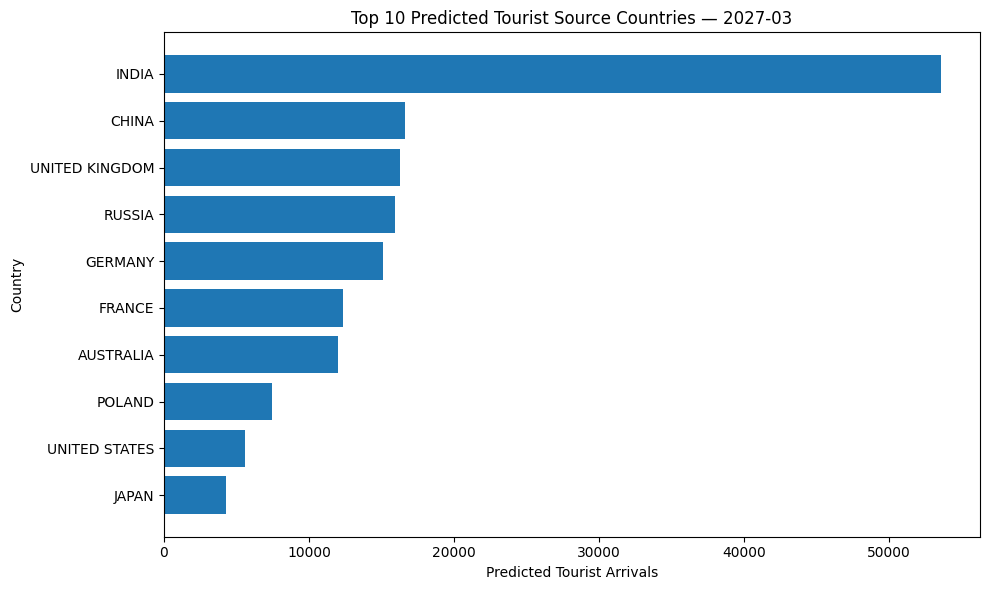

In [40]:
# ==========================================
# TOP 10 PREDICTED COUNTRIES — GRAPH
# ==========================================

plot_top_predicted_countries(
    2027,
    3,
    10
)

In [41]:
# ============================================================
# FINAL TOURIST ARRIVAL FORECAST DASHBOARD
# ============================================================

import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import pandas as pd


# ------------------------------------------------------------
# 1. AVAILABLE OPTIONS
# ------------------------------------------------------------

available_years = sorted(
    country_month_forecast["Date"].dt.year.unique()
)

available_countries = sorted(
    country_month_forecast["Country_Clean"].unique()
)

country_options = ["ALL COUNTRIES"] + available_countries

month_options = [
    ("January", 1),
    ("February", 2),
    ("March", 3),
    ("April", 4),
    ("May", 5),
    ("June", 6),
    ("July", 7),
    ("August", 8),
    ("September", 9),
    ("October", 10),
    ("November", 11),
    ("December", 12)
]


# ------------------------------------------------------------
# 2. CREATE WIDGETS
# ------------------------------------------------------------

country_select = widgets.Dropdown(
    options=country_options,
    value="ALL COUNTRIES",
    description="Country:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="450px")
)

year_select = widgets.Dropdown(
    options=available_years,
    value=2027 if 2027 in available_years else available_years[0],
    description="Year:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="300px")
)

month_select = widgets.Dropdown(
    options=month_options,
    value=3,
    description="Month:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="300px")
)

top_n_select = widgets.Dropdown(
    options=[5, 10, 15, 20],
    value=10,
    description="Top countries:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="300px")
)

predict_button = widgets.Button(
    description="GENERATE FORECAST",
    button_style="primary",
    icon="line-chart",
    layout=widgets.Layout(
        width="250px",
        height="40px"
    )
)

dashboard_output = widgets.Output()


# ------------------------------------------------------------
# 3. DASHBOARD FUNCTION
# ------------------------------------------------------------

def generate_dashboard(button):

    with dashboard_output:

        clear_output(wait=True)

        selected_country = country_select.value
        selected_year = int(year_select.value)
        selected_month = int(month_select.value)
        top_n = int(top_n_select.value)

        selected_date = pd.Timestamp(
            year=selected_year,
            month=selected_month,
            day=1
        )

        month_name = selected_date.strftime("%B")


        # ====================================================
        # A. GET ALL COUNTRY PREDICTIONS FOR SELECTED MONTH
        # ====================================================

        monthly_country_data = country_month_forecast[
            country_month_forecast["Date"] == selected_date
        ].copy()

        if monthly_country_data.empty:

            print(
                "⚠️ Forecast is not available "
                "for this period."
            )

            return


        # ====================================================
        # B. TOTAL SRI LANKA PREDICTION
        # ====================================================

        total_prediction = (
            monthly_country_data[
                "Predicted_Arrivals"
            ].sum()
        )

        total_prediction = int(
            round(total_prediction)
        )


        # ====================================================
        # C. SELECTED COUNTRY PREDICTION
        # ====================================================

        selected_country_prediction = None

        if selected_country != "ALL COUNTRIES":

            country_result = monthly_country_data[
                monthly_country_data[
                    "Country_Clean"
                ] == selected_country
            ]

            if not country_result.empty:

                selected_country_prediction = int(
                    round(
                        country_result[
                            "Predicted_Arrivals"
                        ].iloc[0]
                    )
                )


        # ====================================================
        # D. TOP COUNTRIES
        # ====================================================

        top_countries = (
            monthly_country_data
            .sort_values(
                "Predicted_Arrivals",
                ascending=False
            )
            .head(top_n)
            .copy()
        )

        top_countries = top_countries.sort_values(
            "Predicted_Arrivals"
        )


        # ====================================================
        # E. DASHBOARD HEADER
        # ====================================================

        print("\n")
        print("=" * 75)
        print("       🇱🇰 SRI LANKA TOURIST ARRIVAL FORECAST")
        print("=" * 75)

        print(
            f"\n📅 Forecast Period: "
            f"{month_name} {selected_year}"
        )


        # ====================================================
        # F. TOTAL FORECAST
        # ====================================================

        print("\n")
        print("🇱🇰 TOTAL PREDICTED ARRIVALS TO SRI LANKA")
        print("-" * 50)

        print(
            f"{total_prediction:,} tourists"
        )


        # ====================================================
        # G. SELECTED COUNTRY
        # ====================================================

        if selected_country != "ALL COUNTRIES":

            print("\n")
            print(
                f"🌍 PREDICTION FOR {selected_country}"
            )

            print("-" * 50)

            if selected_country_prediction is not None:

                print(
                    f"{selected_country_prediction:,} tourists"
                )

            else:

                print(
                    "No prediction available."
                )


        # ====================================================
        # H. TOP COUNTRY TABLE
        # ====================================================

        print("\n")
        print(
            f"🌍 TOP {top_n} PREDICTED SOURCE COUNTRIES"
        )

        print("-" * 50)

        display_table = top_countries[
            [
                "Country_Clean",
                "Predicted_Arrivals"
            ]
        ].copy()

        display_table.insert(
            0,
            "Rank",
            range(1, len(display_table) + 1)
        )

        display_table = display_table.rename(
            columns={
                "Country_Clean": "Country",
                "Predicted_Arrivals":
                    "Predicted Arrivals"
            }
        )

        display_table[
            "Predicted Arrivals"
        ] = display_table[
            "Predicted Arrivals"
        ].map(
            lambda x: f"{int(round(x)):,}"
        )

        display(display_table)


        # ====================================================
        # I. BAR CHART
        # ====================================================

        plt.figure(
            figsize=(11, 7)
        )

        plt.barh(
            top_countries["Country_Clean"],
            top_countries["Predicted_Arrivals"]
        )

        plt.xlabel(
            "Predicted Tourist Arrivals"
        )

        plt.ylabel(
            "Country"
        )

        plt.title(
            f"Top {top_n} Predicted Tourist Source Countries\n"
            f"{month_name} {selected_year}"
        )

        plt.tight_layout()

        plt.show()


        # ====================================================
        # J. FINAL INTERPRETATION
        # ====================================================

        highest_country = (
            monthly_country_data
            .sort_values(
                "Predicted_Arrivals",
                ascending=False
            )
            .iloc[0]
        )

        print("\n")
        print("=" * 75)
        print("KEY FORECAST INSIGHT")
        print("=" * 75)

        print(
            f"For {month_name} {selected_year}, "
            f"{highest_country['Country_Clean']} "
            f"has the highest predicted tourist arrivals "
            f"with approximately "
            f"{int(round(highest_country['Predicted_Arrivals'])):,} "
            f"tourists."
        )

        print("=" * 75)


# ------------------------------------------------------------
# 4. CONNECT BUTTON
# ------------------------------------------------------------

predict_button.on_click(
    generate_dashboard
)


# ------------------------------------------------------------
# 5. DISPLAY DASHBOARD
# ------------------------------------------------------------

display(
    widgets.VBox([
        country_select,
        year_select,
        month_select,
        top_n_select,
        predict_button,
        dashboard_output
    ])
)

In [42]:
# ==========================================
# FINAL MODEL RESULTS SUMMARY
# ==========================================

results_summary = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R²"
    ],
    "2025 Validation": [
        round(mae_validation, 2),
        round(rmse_validation, 2),
        round(r2_validation, 4)
    ],
    "2026 Test": [
        round(mae_test, 2),
        round(rmse_test, 2),
        round(r2_test, 4)
    ]
})

display(results_summary)

,Metric,2025 Validation,2026 Test
0,MAE,230.5100,282.1400
1,RMSE,1040.8900,1200.9400
2,R²,0.9364,0.9209


In [43]:
# ==========================================
# RELATIVE MAE
# ==========================================

mean_test_arrivals = y_test.mean()

relative_mae = (
    mae_test / mean_test_arrivals
) * 100

print(
    "Mean actual arrivals in 2026 test set:",
    round(mean_test_arrivals, 2)
)

print(
    "MAE as percentage of mean arrivals:",
    round(relative_mae, 2),
    "%"
)

Mean actual arrivals in 2026 test set: 980.14
MAE as percentage of mean arrivals: 28.79 %


In [44]:
# ==========================================
# BEST AND WORST TEST PREDICTIONS
# ==========================================

test_results = test_df[
    [
        "Year",
        "Month",
        "Country_Clean",
        "Tourist_Arrivals"
    ]
].copy()

test_results["Predicted_Arrivals"] = y_test_pred

test_results["Absolute_Error"] = (
    abs(
        test_results["Tourist_Arrivals"]
        -
        test_results["Predicted_Arrivals"]
    )
)

# Largest errors
largest_errors = (
    test_results
    .sort_values(
        "Absolute_Error",
        ascending=False
    )
    .head(10)
)

print("10 Largest Prediction Errors")

display(largest_errors)

10 Largest Prediction Errors


,Year,Month,Country_Clean,Tourist_Arrivals,Predicted_Arrivals,Absolute_Error
7855,2026,5,INDIA,60342.0,39089.358343,21252.641657
7852,2026,2,INDIA,47679.0,33508.384385,14170.615615
7853,2026,3,INDIA,47533.0,35346.054617,12186.945383
7859,2026,9,INDIA,51931.0,39804.628426,12126.371574
7851,2026,1,INDIA,52061.0,40096.996676,11964.003324
19096,2026,3,UNITED KINGDOM,18092.0,28992.036312,10900.036312
7857,2026,7,INDIA,44547.0,34054.373556,10492.626444
14249,2026,3,POLAND,1139.0,10392.960481,9253.960481
7856,2026,6,INDIA,43423.0,34226.399306,9196.600694
7854,2026,4,INDIA,42645.0,33716.921306,8928.078694


In [45]:
# ==========================================
# ERROR BY COUNTRY
# ==========================================

country_error_summary = (
    test_results
    .groupby("Country_Clean")
    .agg(
        Mean_Absolute_Error=(
            "Absolute_Error",
            "mean"
        ),
        Actual_Arrivals=(
            "Tourist_Arrivals",
            "sum"
        ),
        Predicted_Arrivals=(
            "Predicted_Arrivals",
            "sum"
        )
    )
    .sort_values(
        "Mean_Absolute_Error",
        ascending=False
    )
)

display(
    country_error_summary.head(15)
)

,Mean_Absolute_Error,Actual_Arrivals,Predicted_Arrivals
Country_Clean,,,
INDIA,12012.936079,437414.0,329297.575290
UNITED KINGDOM,4661.237916,160727.0,166036.346071
FRANCE,2980.829556,78860.0,86104.324285
NETHERLANDS,2628.562280,41343.0,47176.472087
RUSSIA,2526.756497,82991.0,105731.808472
GERMANY,2511.832102,97278.0,102263.258536
POLAND,2188.387027,27230.0,41772.520377
CHINA,2006.600739,112550.0,113447.368566
UNITED STATES,1227.201322,45686.0,54755.046583


In [46]:
# ==========================================
# SAVE FUTURE FORECAST
# ==========================================

future_forecast.to_csv(
    "tourist_arrival_forecast_2026_2031_by_country.csv",
    index=False
)

monthly_forecast.to_csv(
    "tourist_arrival_forecast_2026_2031_monthly.csv",
    index=False
)

annual_forecast.to_csv(
    "tourist_arrival_forecast_2026_2031_annual.csv",
    index=False
)

country_annual_forecast.to_csv(
    "tourist_arrival_forecast_2026_2031_country_annual.csv",
    index=False
)

print("All forecast files saved successfully.")

All forecast files saved successfully.


In [47]:
from google.colab import files

files.download(
    "tourist_arrival_forecast_2026_2031_monthly.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
display(annual_forecast)

,Year,Predicted_Arrivals
0,2026,660254
1,2027,2473036
2,2028,2579713
3,2029,2656167
4,2030,2716864
5,2031,2783073


In [49]:
display(
    monthly_forecast.head(10)
)

display(
    monthly_forecast.tail(10)
)

,Date,Predicted_Arrivals
0,2026-10-01,176395
1,2026-11-01,217836
2,2026-12-01,266023
3,2027-01-01,278047
4,2027-02-01,286188
5,2027-03-01,217325
6,2027-04-01,157884
7,2027-05-01,144535
8,2027-06-01,140661
9,2027-07-01,198747


,Date,Predicted_Arrivals
53,2031-03-01,246120
54,2031-04-01,192004
55,2031-05-01,161191
56,2031-06-01,162775
57,2031-07-01,214643
58,2031-08-01,215939
59,2031-09-01,191132
60,2031-10-01,194383
61,2031-11-01,250423
62,2031-12-01,309066
